# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [2]:
!python -m pip install kaggle==1.6.12

In [5]:
%pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

**Note:** Restart the kernel to use updated package(s).

In [7]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd
import numpy as np

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Urban air quality management is complicated by the fact that meteorological conditions—such as wind speed, temperature, and humidity—significantly influence pollutant dispersion and concentration, often obscuring the true impact of emission sources. This project addresses the challenge of quantifying these weather-driven variations by integrating historical hourly weather data with air quality measurements to distinguish between pollution caused by human activity and that exacerbated by atmospheric stagnation

#### Research Questions
1. To what extent do meteorological conditions (wind speed, temperature, pressure) influence PM2.5 concentration?
2. Can pollution driven by human activity be distinguished from pollution exacerbated by atmospheric stagnation?
3. Based on meteorological conditions, which cities experience atmospheric conditions most favourable for air quality?

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

**Historical Hourly Weather Data 2012-2017**

This data contains ~5 years of hourly weather attributes (temprature, humidity, wind speed, etc.) for 20+ cities in the United States/Canada and six Isreali cities. The reason for choosing this dataset is to used the weather attributes to analyze the impact of meteorological conditions on air pollution levels. It contains a comprehensive set of variables that can be used to understand how weather patterns influence air quality and also has Quality and Tidiness issues.

**Quality Issues**:
1. Missing Data Gaps: As with most long-term hourly records, there are significant periods of missing observations (e.g., surface pressure data often has >99% gaps in certain stations prior to 2005, though this dataset focuses on 2012-2017, random hourly dropouts still occur).
2. Outliers/Spurious Values: Sensor errors can introduce impossible values (e.g., negative humidity or extreme pressure spikes) that require filtering to prevent skewing statistical models.

**Tidiness Issues**:
1. Wide Format (Variables in Columns): Each city has its own column for every attribute (e.g., Chicago_Temperature, Vancouver_Temperature). This violates tidy data principles where each row should be an observation and each column a variable. It requires "melting" or pivoting to a long format for analysis.
2. Separate Files per Attribute: Temperature, humidity, and pressure are often stored in separate CSV files with the same time index, requiring multiple joins just to create a single complete weather record.

Type: *CSV Files*

Method: *The data was gathered using programmatic method from kaggle, see the function load_data()*

Dataset variables:

*   *Variable 1 datetime, city, Country, weather, wind_speed, pressure, humidity*
*   *Variable 2 city attributes (each city is a variable)*

In [474]:
WEATHER_DATASET = "selfishgene/historical-hourly-weather-data"
WEATHER_FILES = [
    "city_attributes.csv",
    "temperature.csv",
    "humidity.csv",
    "pressure.csv",
    "wind_speed.csv",
    "weather_description.csv",
    "wind_direction.csv",
]

In [475]:

def load_data() -> dict[str, pd.DataFrame]:
    """ 
        Download the full dataset in one API call, then read each file locally.

        Retruns a dict keyed by variable name e.g. data["pressure"]
    """

    dataset_path = kagglehub.dataset_download(WEATHER_DATASET)
    
    return {
        f.replace(".csv", ""): pd.read_csv(os.path.join(dataset_path, f))
        for f in WEATHER_FILES
    }


In [477]:
data = load_data()

In [478]:
# 1st data gathering and loading method
df_temprature    = data["temperature"]
df_humidity      = data["humidity"]
df_pressure      = data["pressure"]
df_wind_speed    = data["wind_speed"]
df_weather_desc  = data["weather_description"]
df_attributes    = data["city_attributes"]

In [479]:
def inspect_data(df):
    print("=" * 30)
    print(f"\nShape of the Data\n {df.shape}\n")
    print(f"\nData Info\n {df.info()}\n")
    print(f"Data types\n {df.dtypes}\n")
    print(f"Data description\n {df.describe()}\n")
    print(f"Number of Null Data\n {df.isnull().sum()}\n")
    print(df.head())


In [480]:
# Step 1 — inspect all
all_dfs = [("df_temperature",   df_temperature),
                 ("df_humidity",      df_humidity),
                 ("df_pressure",      df_pressure),
                 ("df_wind_speed",    df_wind_speed),
                 ("df_weather_desc",  df_weather_desc),
                 ("df_attributes",    df_attributes)]

for name, df in all_dfs:
    print(f"\n>>> inspect_data({name})")
    inspect_data(df)

# Step 2
# Q1: confirm temperature unit
df_temperature.iloc[:, 1:].mean().mean()

# Q2: NaN summary across all dataframes
print("\n Null Data")
for name, df in all_dfs:
    total_nulls    = df.isnull().sum().sum()
    cities_affected = (df.isnull().sum()[1:] > 0).sum()
    print(f"{name}: {total_nulls} NaNs across {cities_affected} cities")

print()
# Q3: inconsistent dtypes within df_humidity
df_humidity.iloc[:, 1:].dtypes.unique()

print("\n Date Formats")
# T1: confirm datetime is unparsed string across all files
for name, df in all_dfs:
    if name == "df_attributes":
        continue
    print(f"{name}['datetime'].dtype:", df['datetime'].dtype)

print("\nWide Columns")
# T2: confirm wide format (cities as columns) across all files
for name, df in all_dfs:
    print(f"{name} columns:", df.columns[:5].tolist(), "...")


>>> inspect_data(df_temperature)

Shape of the Data
 (45253, 37)

<class 'pandas.DataFrame'>
RangeIndex: 45253 entries, 0 to 45252
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           45253 non-null  str    
 1   Vancouver          44458 non-null  float64
 2   Portland           45252 non-null  float64
 3   San Francisco      44460 non-null  float64
 4   Seattle            45250 non-null  float64
 5   Los Angeles        45250 non-null  float64
 6   San Diego          45252 non-null  float64
 7   Las Vegas          45252 non-null  float64
 8   Phoenix            45250 non-null  float64
 9   Albuquerque        45252 non-null  float64
 10  Denver             45252 non-null  float64
 11  San Antonio        45252 non-null  float64
 12  Dallas             45249 non-null  float64
 13  Houston            45250 non-null  float64
 14  Kansas City        45252 non-null  float64
 15  Minneapolis   

#### Dataset 2
**Beijing Multi-Site Air-Quality Data Set**

This dataset contains hourly averaged responses from air quality sensors (CO, SO2, NO2, O3) and reference analyzer values, collected in Beijing Municipal Environment Monitoring Center from the period of 2013-2017. 
Assumption for this analysis: We will assume the use of the Beijing Municipal Environment Monitoring Center Air Quality Data (2013-2017) to ensure temporal overlap with the 2012-2017 weather dataset.

**Quality Issues:**

1. Missing Values Tagged Incorrectly: Missing data is often denoted by specific placeholder values like NA mixed within numeric columns, which must be converted to proper null types before calculation.
2. No is documented as "row number" — it simply resets from 1 to 35,064. It carries no unique identity across the full dataset and conflicts with pandas' own index once files are concatenated.

**Tidiness Issues:**

1. Date and Time Split: The Date and Time are often in separate columns (or combined in a non-standard string format like "DD/MM/YYYY" and "HH.MM.SS"), requiring parsing into a single standardized datetime object for merging.
2. Beijing air quality is a single observational unit, the "station" (contains Aotizhongxin all through). The station is a redudant constant.

Type: *CSV file*

Method: *Manual Download from https://www.kaggle.com/datasets/sid321axn/beijing-multisite-airquality-data-set* (e.g., The data was gathered using the "API" method from Y source.)

Dataset variables:

*   *Variable 1 Datetime (year,  month  day  hour), TEMP is Temperature*
*   *PM2.5 (particulate matter with a diameter of 2.5 microns or less)*
*   *Variable 2 PRES is Pressure,  DEWP is Dew Point,   RAIN,   wd is weather description*

In [482]:
# 2nd data gathering and loading method
# manual download from kaggle to data directory

AIR_DATASET = "PRSA_Data_Aotizhongxin_20130301-20170228.csv"

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [561]:
#Optional: store the raw data in your local data store
df_air = pd.read_csv(os.path.join("data/", AIR_DATASET))

In [562]:
inspect_data(df_air)


Shape of the Data
 (35064, 18)

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 5.3 MB

Data Info
 None

Data types
 No           int64
y

In [563]:
df_air['year'].unique()

array([2013, 2014, 2015, 2016, 2017])

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [486]:
# Inspecting the dataframe visually
df_temprature.sample(n=5, random_state=42)

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
21603,2015-03-20 15:00:00,282.146,282.840000,284.665000,283.240000,289.040000,288.165000,284.740000,289.515000,279.615000,...,273.640000,273.396,270.684,270.215000,289.734,290.05,291.134,289.246,287.284,284.39
34366,2016-09-02 10:00:00,286.020,287.110000,287.570000,286.360000,291.780000,290.750000,301.280000,301.900000,287.050000,...,288.860000,290.790,287.080,288.040000,298.939,304.15,306.180,303.630,303.150,304.23
27864,2015-12-06 12:00:00,277.750,280.597569,282.570750,281.638593,285.679049,284.904584,276.547427,279.762018,271.378511,...,270.330267,272.060,276.150,272.345334,285.133,289.15,287.360,286.150,286.150,289.15
30577,2016-03-28 13:00:00,277.200,276.458246,281.341917,276.541092,287.709360,288.521150,289.494009,288.007677,275.722343,...,281.070000,279.410,278.170,276.840000,285.907,291.92,296.150,289.150,289.150,291.75
25531,2015-08-31 07:00:00,287.560,288.820000,291.030000,289.090000,294.270000,293.520000,301.980000,304.600000,292.120000,...,295.540000,296.370,291.780,293.170000,298.158,302.25,304.150,303.500,301.150,302.38


In [487]:
# Inspecting the dataframe programmatically
# Q1 — Confirm temperature unit (Kelvin vs Celsius)
print(f"Confirm Units in kelvin \n {df_temprature.iloc[:, 1:].mean().mean()}\n")

Confirm Units in kelvin 
 288.6126792907677



Issue and justification: 

*Temperature in Kelvin, unlabelled (df_temperature)*

*df_temperature.iloc[:, 1:].mean().mean() returns ~289 — not possible as Celsius for North American cities.*

*No unit is stated anywhere in the file.*

### Quality Issue 2:

# Inspecting the dataframe visually
Missing values (NaN) present across df_temperature, df_humidity, df_pressure, df_wind_speed (all variable files)

In [488]:
df_temperature.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN
1,2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,...,285.630000,288.220000,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5
2,2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,...,285.663208,288.247676,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5
3,2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,...,285.756824,288.326940,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5
4,2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,...,285.850440,288.406203,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5


In [489]:
# Inspecting the dataframe programmatically
# Q2 Check NaN pattern: are gaps aligned across cities or isolated?
null_mask = df_temperature.isnull()
df_temperature[null_mask.any(axis=1)][['datetime', 'Vancouver', 'San Francisco', 'Las Vegas']]

,datetime,Vancouver,San Francisco,Las Vegas
0,2012-10-01 12:00:00,NaN,NaN,NaN
3859,2013-03-11 07:00:00,NaN,281.998,283.353333
3860,2013-03-11 08:00:00,NaN,280.756,282.786667
4623,2013-04-12 03:00:00,283.56,290.720,292.430000
4624,2013-04-12 04:00:00,282.89,288.610,290.900000
...,...,...,...,...
45248,2017-11-29 20:00:00,NaN,NaN,289.540000
45249,2017-11-29 21:00:00,NaN,NaN,290.610000
45250,2017-11-29 22:00:00,NaN,NaN,291.340000
45251,2017-11-29 23:00:00,NaN,NaN,292.150000


Issue and justification:

*NaN counts vary by city and file with no documented reason. The same cities (Vancouver, San Francisco, Las Vegas) are affected across multiple files at the same rows, indicating a station outage — but nothing in the data flags this.*

### Tidiness Issue 1:

# Inspecting the dataframe visually
Tidiness Issues (drawn from all dataframes)
datetime is an unparsed string across all variable files (df_temperature, df_humidity, df_pressure, df_wind_speed, df_weather_desc)

In [490]:
#Inspecting the dataframe programmatically
for name, df in all_dfs:
    if name == "df_attributes":
        continue
    print(f"{name}['datetime'].dtype:", df['datetime'].dtype)

df_temperature['datetime'].dtype: str
df_humidity['datetime'].dtype: str
df_pressure['datetime'].dtype: str
df_wind_speed['datetime'].dtype: str
df_weather_desc['datetime'].dtype: str


Issue and justification: 

*datetime dtype is str in every file.*

*No time-series operation works without datetime data type pd.to_datetime() applied first.*

### Tidiness Issue 2: 

# Inspecting the dataframe visually
T2 — Wide format: cities are column headers, not a variable (all variable files)

In [491]:
# Inspecting the dataframe programmatically
# T2: confirm wide format (cities as columns) across all files
for name, df in all_dfs:
    print(f"{name} columns:", df.columns[:5].tolist(), "...")

df_temperature columns: ['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle'] ...
df_humidity columns: ['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle'] ...
df_pressure columns: ['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle'] ...
df_wind_speed columns: ['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle'] ...
df_weather_desc columns: ['datetime', 'Vancouver', 'Portland', 'San Francisco', 'Seattle'] ...
df_attributes columns: ['City', 'Country', 'Latitude', 'Longitude'] ...


All five files have 36 city-name columns. City is a variable and should be a single city column. Confirmed identical structure across all files via .columns.tolist().

## Dataset 2

### Quality Issue 1

In [492]:
# Inspecting the dataframe visually
df_air.sample(n=20, random_state=42)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
6070,6071,2013,11,8,22,162.0,198.0,88.0,110.0,3200.0,NaN,4.4,1015.5,1.8,0.0,ESE,0.1,Aotizhongxin
32600,32601,2016,11,18,8,175.0,240.0,11.0,85.0,3900.0,2.0,6.6,1012.1,2.9,0.0,NE,1.5,Aotizhongxin
8846,8847,2014,3,4,14,7.0,22.0,7.0,9.0,400.0,78.0,9.3,1019.5,-19.8,0.0,WNW,3.9,Aotizhongxin
1483,1484,2013,5,1,19,39.0,116.0,17.0,28.0,500.0,NaN,19.3,1006.6,1.3,0.0,SW,3.1,Aotizhongxin
4219,4220,2013,8,23,19,18.0,49.0,3.0,64.0,500.0,89.0,25.7,1003.2,17.1,0.0,SW,0.7,Aotizhongxin
7289,7290,2013,12,29,17,37.0,78.0,NaN,77.0,900.0,10.0,0.5,1010.9,-16.4,0.0,SW,0.1,Aotizhongxin
12994,12995,2014,8,24,10,11.0,19.0,18.0,28.0,300.0,48.0,27.9,1001.5,10.6,0.0,N,2.8,Aotizhongxin
9026,9027,2014,3,12,2,3.0,5.0,4.0,16.0,300.0,62.0,7.3,1019.0,-10.0,0.0,NE,3.0,Aotizhongxin
23516,23517,2015,11,5,20,22.0,22.0,8.0,29.0,500.0,33.0,3.5,1028.7,-0.3,0.0,NE,3.5,Aotizhongxin
32732,32733,2016,11,23,20,9.0,18.0,3.0,29.0,400.0,48.0,1.6,1029.5,-17.4,0.0,NW,3.5,Aotizhongxin


In [493]:
# Inspecting the dataframe programmatically
df_air.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

Missing Values Tagged Incorrectly: Missing data is often denoted by specific placeholder values like NAN mixed within numeric columns.

### Quality Issue 2

The table view above

pandas index is 6070 - 30391

No is 6071 - 30392

No is documented as "row number" — it simply resets from 1 to 35,064. It carries no unique identity across the full dataset and conflicts with pandas' own index once files are concatenated.

### Tidiness Issue 1


In [494]:
print(df_air[['year', 'month', 'day', 'hour']].head())
print(df_air[['year', 'month', 'day', 'hour']].dtypes)

   year  month  day  hour
0  2013      3    1     0
1  2013      3    1     1
2  2013      3    1     2
3  2013      3    1     3
4  2013      3    1     4
year     int64
month    int64
day      int64
hour     int64
dtype: object


Date and Time Split: The Date and Time are often in separate columns (or combined in a non-standard string format like "DD/MM/YYYY" and "HH.MM.SS"), requiring parsing into a single standardized datetime object for merging.


### Tidiness issue 2

In [503]:
print(df_air['station'].nunique())   # returns 1
print(df_air['station'].unique()) 

1
<ArrowStringArray>
['Aotizhongxin']
Length: 1, dtype: str


Beijing air quality is a single observational unit, the "station" (contains Aotizhongxin all through). The station is a redudant constant.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

### **Quality Issue 1:**

In [496]:
# Q1 — Confirm temperature unit (Kelvin vs Celsius)
print(f"Confirm Units in kelvin \n {df_temprature.iloc[:, 1:].mean().mean()}\n")

Confirm Units in kelvin 
 288.6126792907677



In [508]:
df_weather = df_weather.sort_values(by=['city', 'datetime'])

### Dataset 2: **Tidiness Issue 1: combine year/month/day/hour into a single datetime column**

In [564]:

df_air['datetime'] = pd.to_datetime(df_air[['year', 'month', 'day', 'hour']])
df_air.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)

In [565]:
# Validate the cleaning was successful
df_air.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   No        35064 non-null  int64         
 1   PM2.5     34139 non-null  float64       
 2   PM10      34346 non-null  float64       
 3   SO2       34129 non-null  float64       
 4   NO2       34041 non-null  float64       
 5   CO        33288 non-null  float64       
 6   O3        33345 non-null  float64       
 7   TEMP      35044 non-null  float64       
 8   PRES      35044 non-null  float64       
 9   DEWP      35044 non-null  float64       
 10  RAIN      35044 non-null  float64       
 11  wd        34983 non-null  str           
 12  WSPM      35050 non-null  float64       
 13  station   35064 non-null  str           
 14  datetime  35064 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(11), int64(1), str(2)
memory usage: 4.5 MB


### Validate the cleaning was successful

In [566]:
# Validate the cleaning was successful
assert not {'year', 'month', 'day', 'hour'}.issubset(df_air.columns)  # all 4 dropped
print(f"T1 ✓  index = {df_air.index[0]} → {df_air.index[-1]}")

T1 ✓  index = 0 → 35063


Justification: *replaced 4 columns with datetime*

### Dataset 2: **Tidiness Issue 2 — drop constant station column (single-file scope)**

In [567]:
# T2 — drop constant station column (single-file scope)
df_air.drop(columns=['station'], inplace=True)

In [568]:
#FILL IN - Validate the cleaning was successful
assert 'station' not in df_air.columns
print(f"T2 ✓  station column gone, shape = {df_air.shape}")

T2 ✓  station column gone, shape = (35064, 14)


### Dataset 2: **Q1 — missing values: drop rows where ALL pollutants are NaN (sensor outage)**

In [569]:
# Dataset2, Q1 — missing values: drop rows where ALL pollutants are NaN (sensor outage)
# interpolate remaining gaps (time-series continuity)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
df_air.dropna(subset=pollutants, how='all', inplace=True)
df_air.set_index('datetime', inplace=True)
df_air[pollutants] = df_air[pollutants].interpolate(method='time')

In [570]:
df_air.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34427 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      34427 non-null  int64  
 1   PM2.5   34427 non-null  float64
 2   PM10    34427 non-null  float64
 3   SO2     34427 non-null  float64
 4   NO2     34427 non-null  float64
 5   CO      34427 non-null  float64
 6   O3      34427 non-null  float64
 7   TEMP    34407 non-null  float64
 8   PRES    34407 non-null  float64
 9   DEWP    34407 non-null  float64
 10  RAIN    34407 non-null  float64
 11  wd      34346 non-null  str    
 12  WSPM    34413 non-null  float64
dtypes: float64(11), int64(1), str(1)
memory usage: 3.8 MB


### Validate the cleaning was successful

In [571]:
# Validate the cleaning was successful
remaining_nulls = df_air[pollutants].isnull().sum()
assert remaining_nulls.sum() == 0, f"Still has NaNs:\n{remaining_nulls}"
print(f"Q2 ✓  zero NaNs in pollutant columns\n{remaining_nulls}")

Q2 ✓  zero NaNs in pollutant columns
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
dtype: int64


In [572]:
assert 'datetime' not in df_air.columns          # moved to index
assert df_air.index.dtype == 'datetime64[us]'    # correctly parsed

In [573]:
print(df_air.index)
print(df_air.index[0], df_air.index[1])

DatetimeIndex(['2013-03-01 00:00:00', '2013-03-01 01:00:00',
               '2013-03-01 02:00:00', '2013-03-01 03:00:00',
               '2013-03-01 04:00:00', '2013-03-01 05:00:00',
               '2013-03-01 06:00:00', '2013-03-01 07:00:00',
               '2013-03-01 08:00:00', '2013-03-01 09:00:00',
               ...
               '2017-02-28 14:00:00', '2017-02-28 15:00:00',
               '2017-02-28 16:00:00', '2017-02-28 17:00:00',
               '2017-02-28 18:00:00', '2017-02-28 19:00:00',
               '2017-02-28 20:00:00', '2017-02-28 21:00:00',
               '2017-02-28 22:00:00', '2017-02-28 23:00:00'],
              dtype='datetime64[us]', name='datetime', length=34427, freq=None)
2013-03-01 00:00:00 2013-03-01 01:00:00


### Dataset 2: **Q2 drop redundant row index**

In [574]:
# Dataset 2 - Apply the cleaning strategy
# Q2 — drop redundant row index

df_air.drop(columns=['No'], inplace=True)

In [575]:
# Validate the cleaning was successful
assert 'No' not in df.columns
print(f"Q2 ✓  No column gone")

Q2 ✓  No column gone


Justification: *Pandas series is will suffice for the No removal with no more contradiction*

### Additional Cleaning to match df_weather

In [576]:
# Then rename df_air columns to match df_weather.
df_air.rename(columns={
    'TEMP' : 'temperature',
    'PRES' : 'pressure',
    'WSPM' : 'wind_speed'
}, inplace=True)


### Verify the columns renaming

In [577]:
df_air.head(1)

,PM2.5,PM10,SO2,NO2,CO,O3,temperature,pressure,DEWP,RAIN,wd,wind_speed
datetime,,,,,,,,,,,,
2013-03-01,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4


In [ ]:
cols_to_fill = ['temperature', 'pressure', 'DEWP', 'weather_desc']
df_weather[cols_to_fill] = df_weather.groupby('city')[cols_to_fill].ffill()

### Dataset 1: **T2 Wide format: cities are column headers, not a variable (all variable files)**

In [523]:
# # Make copies of the datasets to ensure the raw dataframes 
# are not impacted
df_temp = df_temperature.copy()
df_pres = df_pressure.copy()
df_hum  = df_humidity.copy()
df_wind = df_wind_speed.copy()
df_weather = df_weather_desc.copy()
df_attr    = df_attributes.copy()

dfs = [("temperature",   df_temp),
       ("humidity",      df_hum),
       ("pressure",      df_pres),
       ("wind_speed",    df_wind),
       ("weather_desc",  df_weather),
       ("attributes",    df_attr)]

In [524]:
df_attr.head(3)

,City,Country,Latitude,Longitude
0,Vancouver,Canada,49.249660,-123.119339
1,Portland,United States,45.523449,-122.676208
2,San Francisco,United States,37.774929,-122.419418


In [525]:
# Converting wide DataFrame(s) to long
melted_dfs = []

for name, df in dfs:
    if name == "attributes":
        continue   
    df_melted = df.melt(
        id_vars=['datetime'],       # Keep the datetime column as-is (the index)
        var_name='city',         # New column name for the old headers
        value_name=name     # New column name for the values
    )
    melted_dfs.append(df_melted)

df_weather = pd.concat(melted_dfs, ignore_index=True)

df_weather.sample(20)

,datetime,city,temperature,humidity,pressure,wind_speed,weather_desc
4855140,2014-03-30 01:00:00,Jerusalem,NaN,NaN,1007.0,NaN,NaN
6821176,2016-07-16 22:00:00,Las Vegas,NaN,NaN,NaN,NaN,sky is clear
7191560,2017-06-30 06:00:00,Minneapolis,NaN,NaN,NaN,NaN,light rain
330752,2014-05-07 01:00:00,Phoenix,296.88,NaN,NaN,NaN,NaN
6089890,2015-09-19 08:00:00,Philadelphia,NaN,NaN,NaN,1.0,NaN
3620244,2012-10-01 16:00:00,Albuquerque,NaN,NaN,1024.0,NaN,NaN
769200,2017-11-25 20:00:00,Chicago,282.84,NaN,NaN,NaN,NaN
2921333,2015-08-15 01:00:00,Montreal,NaN,94.0,NaN,NaN,NaN
4218755,2013-12-01 14:00:00,Jacksonville,NaN,NaN,1021.0,NaN,NaN
1991927,2012-11-03 15:00:00,Albuquerque,NaN,24.0,NaN,NaN,NaN


### Dataset 1: **T1 Converting Datetime to pandas datetime**

In [526]:
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'], errors='coerce')

Validating convertion

In [527]:
print(df_weather['datetime'].dtype)

datetime64[us]


### **Dataset 1: Q2 - Apply the cleaning strategy to Nan**

In [528]:
# Q2 - Apply the cleaning strategy to Nan
df_weather.isnull().sum() / len(df_weather) * 100

datetime         0.000000
city             0.000000
temperature     80.098582
humidity        80.351738
pressure        80.204775
wind_speed      80.098127
weather_desc    80.097661
dtype: float64

In [529]:
cols_to_fill = ['temperature', 'humidity', 'pressure', 'wind_speed', 'weather_desc']
df_weather[cols_to_fill] = df_weather.groupby('city')[cols_to_fill].ffill()

ffill(): Propagates the last valid sensor reading forward, which is physically realistic for hourly weather data (e.g., if the 2:00 PM reading is missing, it's likely very similar to the 1:00 PM reading).

In [530]:
df_weather[cols_to_fill] = df_weather.groupby('city')[cols_to_fill].bfill()

bfill(): fill the remaining nans backward that reading forward did not fill

### **Validate the cleaning was successful**

In [531]:
df_weather.isnull().sum()

datetime        0
city            0
temperature     0
humidity        0
pressure        0
wind_speed      0
weather_desc    0
dtype: int64

### **Dataset 1: Q1 - Converting Temperature to degree celcius**

In [532]:
df_weather['temperature']

0          284.630000
1          284.630000
2          284.629041
3          284.626998
4          284.624955
              ...    
8145535    294.150000
8145536    294.150000
8145537    294.150000
8145538    294.150000
8145539    294.150000
Name: temperature, Length: 8145540, dtype: float64

In [580]:
df_weather['temperature'] = df_weather['temperature'] - 273.15

Justification

Temperature needs to be converted to degree celcius to match the comparing data df_air

### Additional cleaning

In [578]:
# ══════════════════════════════════════════════════════════════════════════════
# Align temporal granularity - Resample data
# ══════════════════════════════════════════════════════════════════════════════
# Rationale: df_air is hourly. df_weather is daily.
# Training on hourly data and predicting on daily data produces mismatched
# scale — hourly PM2.5 spikes would inflate the model's sense of variance.
# Resample df_air to daily means so both datasets operate at the same level.

df_air_daily = (df_air[['PM2.5', 'temperature', 'pressure', 'wind_speed']]
                .resample('D').mean()
                .dropna()
                .reset_index())

print(f"\n df_air resampled to daily")
print(f"  Hourly rows: 34,427 → Daily rows: {len(df_air_daily)}")
print(df_air_daily.head(3).to_string())


 df_air resampled to daily
  Hourly rows: 34,427 → Daily rows: 1446
    datetime      PM2.5  temperature     pressure  wind_speed
0 2013-03-01   7.125000     1.391667  1026.875000    3.254167
1 2013-03-02  30.750000     0.616667  1026.850000    1.479167
2 2013-03-03  76.916667     5.566667  1014.608333    1.658333


In [581]:
# ══════════════════════════════════════════════════════════════════════════════
# Align column names and fix units
# ══════════════════════════════════════════════════════════════════════════════
# Rationale: the same physical variable must have the same name and unit
# in both datasets.
# df_air TEMP is in Celsius. df_weather temperature is in Kelvin.
# Subtract 273.15 to convert.
# DEWP (dew point °C) and humidity (relative humidity %) are both moisture
# measures but numerically incomparable — excluded from shared features.

print(f"\nColumns aligned and units corrected")
print("Shared features available in both datasets:")
print("\n  temperature (°C) | pressure (hPa) | wind_speed (m/s)")

print("\n  df_air temperature range:",
      df_air_daily['temperature'].min().round(1), "→",
      df_air_daily['temperature'].max().round(1), "°C")

print("\n  df_weather temperature range after conversion:",
      df_weather['temperature'].min().round(1), "→",
      df_weather['temperature'].max().round(1), "°C")


Columns aligned and units corrected
Shared features available in both datasets:

  temperature (°C) | pressure (hPa) | wind_speed (m/s)

  df_air temperature range: -15.3 → 32.4 °C

  df_weather temperature range after conversion: -6.0 → 28.6 °C


### verifying T1, the data after unpivot

In [536]:
# verifying the data after unpivot
cities = df_temp.columns[1:]
before = {
    name: {
        "rows":        df.shape[0],
        "cities":      len(df.columns) - 1,
        "total_vals":  df[cities].count().sum(),
        "datetime_min": df["datetime"].min(),
        "datetime_max": df["datetime"].max(),
    }
    for name, df in dfs if name != "attributes"
}


In [537]:
print(f"{'CHECK':<30} {'BEFORE':>10} {'AFTER':>10} {'OK?':>5}")

for name, df in dfs:
    if name in ("attributes", "weather_desc"):
        continue
    b      = before[name]
    melted = [m for m in melted_dfs if name in m.columns][0]

    expected_rows = b["rows"] * b["cities"]
    actual_rows   = len(melted)
    vals_after    = melted[name].count()

    print(f"\n── {name} ──")
    print(f"  {'rows (N × cities)':<28} {expected_rows:>10} {actual_rows:>10} {'✓' if expected_rows == actual_rows else '✗':>5}")
    print(f"  {'non-null values':<28} {b['total_vals']:>10} {vals_after:>10} {'✓' if b['total_vals'] == vals_after else '✗':>5}")
    print(f"  {'unique cities':<28} {b['cities']:>10} {melted['city'].nunique():>10} {'✓' if b['cities'] == melted['city'].nunique() else '✗':>5}")
    print(f"  {'datetime min':<28} {b['datetime_min']:>10} {melted['datetime'].min():>10} {'✓' if b['datetime_min'] == melted['datetime'].min() else '✗':>5}")
    print(f"  {'datetime max':<28} {b['datetime_max']:>10} {melted['datetime'].max():>10} {'✓' if b['datetime_max'] == melted['datetime'].max() else '✗':>5}")

    # spot-check a known cell value
    sample_city = cities[0]
    sample_dt   = df["datetime"].iloc[0]
    val_before  = df.loc[df["datetime"] == sample_dt, sample_city].values[0]
    val_after   = melted.loc[(melted["datetime"] == sample_dt) & (melted["city"] == sample_city), name].values[0]
    match       = (val_before == val_after) or (np.isnan(val_before) and np.isnan(val_after))
    print(f"  {'spot-check value':<28} {str(val_before):>10} {str(val_after):>10} {'✓' if match else '✗':>5}")


CHECK                              BEFORE      AFTER   OK?

── temperature ──
  rows (N × cities)               1629108    1629108     ✓
  non-null values                 1621078    1621078     ✓
  unique cities                        36         36     ✓
  datetime min                 2012-10-01 12:00:00 2012-10-01 12:00:00     ✓
  datetime max                 2017-11-30 00:00:00 2017-11-30 00:00:00     ✓
  spot-check value                    nan        nan     ✓

── humidity ──
  rows (N × cities)               1629108    1629108     ✓
  non-null values                 1600457    1600457     ✓
  unique cities                        36         36     ✓
  datetime min                 2012-10-01 12:00:00 2012-10-01 12:00:00     ✓
  datetime max                 2017-11-30 00:00:00 2017-11-30 00:00:00     ✓
  spot-check value                    nan        nan     ✓

── pressure ──
  rows (N × cities)               1629108    1629108     ✓
  non-null values                 1612428    161242

In [538]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 8145540 entries, 0 to 8145539
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   datetime      datetime64[us]
 1   city          str           
 2   temperature   float64       
 3   humidity      float64       
 4   pressure      float64       
 5   wind_speed    float64       
 6   weather_desc  str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 593.2 MB


### Additional cleaning required to reduce the large memory usage

In [539]:
# dataset is too large with memory usage at 593.2 MB
# need to reduce the memory usage
# filter to overlap window only
mask       = (df_weather['datetime'] >= df_air.index.min()) & \
             (df_weather['datetime'] <= df_air.index.max())
df_weather = df_weather[mask].reset_index(drop=True)

In [540]:
# resample to daily means per city
df_weather = (df_weather.groupby(['city', pd.Grouper(key='datetime', freq='D')])[
                  ['temperature', 'humidity', 'pressure', 'wind_speed']]
              .mean()
              .reset_index())

In [541]:
# downcast floats from float64 to float32
for col in ['temperature', 'humidity', 'pressure', 'wind_speed']:
    df_weather[col] = df_weather[col].astype('float32')

In [542]:
# convert low-cardinality string columns to category
df_weather['city'] = df_weather['city'].astype('category')

In [543]:
print(df_weather.info(memory_usage='deep'))
print(f"\nMemory: {df_weather.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Shape:  {df_weather.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 52596 entries, 0 to 52595
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   city         52596 non-null  category      
 1   datetime     52596 non-null  datetime64[us]
 2   temperature  52596 non-null  float32       
 3   humidity     52596 non-null  float32       
 4   pressure     52596 non-null  float32       
 5   wind_speed   52596 non-null  float32       
dtypes: category(1), datetime64[us](1), float32(4)
memory usage: 1.3 MB
None

Memory: 1.3 MB
Shape:  (52596, 6)


Justification: 

*large dataset requires large memory to read and store*

*Reduction from 593. MB to 1.3 MB, a light weigth is neccessary for speed, efficiency and less resource usage.*

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [599]:
#FILL IN - Remove unnecessary variables and combine datasets
df_combined = pd.concat(
    [df_air_daily.assign(source='beijing'),
     df_weather.assign(source='city_stations')],
    ignore_index=True)

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [276]:
# saving data
df_air.to_csv("data/air_quality_2026_07_13.csv", encoding="utf-8")

In [325]:
df_weather.to_csv("data/weather_2026_07_13.csv", encoding="utf-8")

In [583]:
df_combined.to_csv(
    "data/weather_quality_2026_07_17.csv", encoding="utf-8")

 ## We use only the 3 variables that exist in both datasets.

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

In [547]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

In [548]:

FIG_BG = "#0f1117"; BG = "#1a1a2e"; TEXT = "#e0e0e0"
GRID = "#2a2a3a"; BLUE = "#00bfff"; RED = "#ff6b6b"
GREEN = "#2ecc71"; YELLOW = "#f9ca24"

def style(ax, title, xlabel, ylabel):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=TEXT, fontsize=9)
    ax.set_ylabel(ylabel, color=TEXT, fontsize=9)
    ax.tick_params(colors=TEXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.grid(color=GRID, linewidth=0.5)

In [584]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load data
# ══════════════════════════════════════════════════════════════════════════════
# Rationale: data/weather_quality_2026_07_17.csv has pollution + meteorological measurements from Beijing.
# and has meteorological measurements for 36 cities, no pollution data.
# The bridge between them is the shared meteorological variables.

df_quality = pd.read_csv("data/weather_quality_2026_07_17.csv",
                         index_col=0, parse_dates=['datetime'])

print("STEP 1 — Data loaded")
print(f"  df_quality     : {df_air.shape}  | columns: {df_air.columns.tolist()}")

STEP 1 — Data loaded
  df_quality     : (34427, 12)  | columns: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'temperature', 'pressure', 'DEWP', 'RAIN', 'wd', 'wind_speed']


In [593]:
df_quality.dtypes

datetime       datetime64[us]
temperature           float64
pressure              float64
wind_speed            float64
source                    str
dtype: object

In [600]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Define features and target
# ══════════════════════════════════════════════════════════════════════════════
# Rationale: we use only the 3 variables that exist in both datasets.
# PM2.5 is the target — it is what we want to estimate for the 36 cities.

FEATURES = ['temperature', 'pressure', 'wind_speed']
TARGET   = ['PM2.5']

beijing = df_combined[df_combined['source'] == 'beijing']
X = beijing[FEATURES]
y = beijing[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nSTEP 2 — Features and target defined")
print(f"  Features : {FEATURES}")
print(f"  Target   : {TARGET}")
print(f"  Train    : {len(X_train)} days | Test: {len(X_test)} days")


STEP 2 — Features and target defined
  Features : ['temperature', 'pressure', 'wind_speed']
  Target   : ['PM2.5']
  Train    : 1156 days | Test: 290 days


In [614]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Model selection
# ══════════════════════════════════════════════════════════════════════════════
# wind_speed plateaus at high speeds — diminishing dispersion returns
# temperature has a threshold effect — inversion kicks in sharply below ~5°C
# These are non-linear. Linear Regression cannot capture them.
# Random Forest learns these curves directly without assumptions.
# It is also robust to PM2.5 outliers (max=512 µg/m³ in the training data).

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train.values.ravel())  # .values.ravel() to resample it to 1d vector (n_samples=1)

y_pred = model.predict(X_test)
r2     = r2_score(y_test, y_pred)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.2f} µg/m³")
print(f"\nFeature importances:")

for f, i in zip(FEATURES, model.feature_importances_):
    print(f"  {f}: {i:.3f}")

R²   = 0.237
RMSE = 62.20 µg/m³

Feature importances:
  temperature: 0.344
  pressure: 0.282
  wind_speed: 0.375


In [612]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Apply model to 36 cities
# ══════════════════════════════════════════════════════════════════════════════
# Rationale: the model learned how Beijing's met conditions map to PM2.5.
# Applying it to the 36 cities gives an estimated PM2.5 for each city
# based on how similar their met conditions are to Beijing's clean vs
# polluted days. We average daily predictions to get one value per city.

cities = df_combined[df_combined['source'] == 'city_stations']

df_combined.loc[df_combined['source'] == 'city_stations', 'predicted_PM2.5'] = \
    model.predict(cities[FEATURES])

print(cities[['city', 'predicted_PM2.5']].groupby('city').mean().sort_values('predicted_PM2.5').round(2))

                   predicted_PM2.5
city                              
Philadelphia                 27.05
New York                     27.21
Eilat                        27.80
Miami                        28.36
Montreal                     32.62
Denver                       32.82
Albuquerque                  33.29
Saint Louis                  35.49
Indianapolis                 39.43
Boston                       40.41
Atlanta                      42.12
Charlotte                    43.34
Toronto                      47.51
Nashville                    47.52
Dallas                       48.49
Minneapolis                  54.90
Jacksonville                 56.04
Seattle                      60.05
San Francisco                66.78
Phoenix                      69.03
Jerusalem                    69.32
Nahariyya                    72.32
Haifa                        72.91
Houston                      79.16
Chicago                      82.58
Tel Aviv District            89.23
Los Angeles         

<Figure size 1800x1600 with 0 Axes>

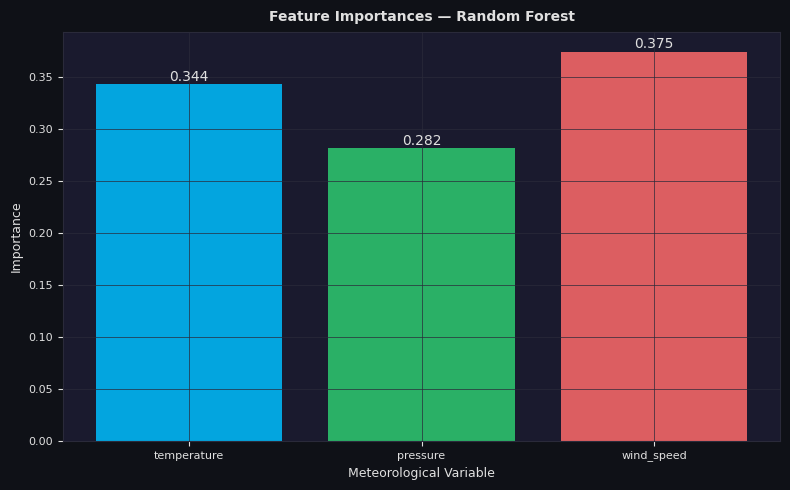

In [615]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Plots
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 16), facecolor=FIG_BG)
fig.suptitle("City Air Quality Ranking — Random Forest Trained on Beijing Data",
             color='white', fontsize=13, fontweight='bold')

gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.35)

# ── Plot 1: Feature importances ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)
bars = ax.bar(FEATURES, model.feature_importances_,
              color=[BLUE, GREEN, RED], alpha=0.85)
for bar, val in zip(bars, model.feature_importances_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', color=TEXT, fontsize=10)
style(ax, "Feature Importances — Random Forest",
      "Meteorological Variable", "Importance")
plt.tight_layout()
plt.show()

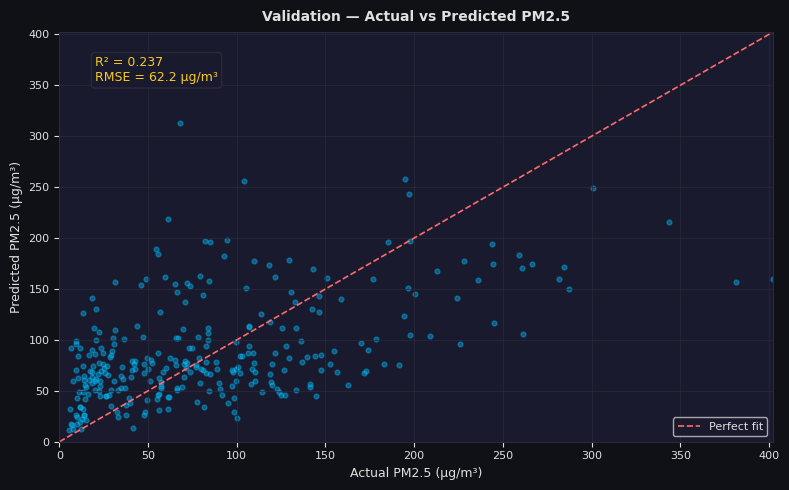

In [617]:
# ── Plot 2: Actual vs Predicted ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)
ax.scatter(y_test, y_pred, alpha=0.4, s=12, color=BLUE)
lims = [0, max(y_test.values.max(), y_pred.max())]
ax.plot(lims, lims, color=RED, linewidth=1.2, linestyle='--', label='Perfect fit')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.text(0.05, 0.88,
        f'R² = {r2:.3f}\nRMSE = {rmse:.1f} µg/m³',
        transform=ax.transAxes, color=YELLOW, fontsize=9,
        bbox=dict(facecolor=BG, edgecolor=GRID, boxstyle='round'))
ax.legend(fontsize=8, labelcolor=TEXT, facecolor=BG)
style(ax, "Validation — Actual vs Predicted PM2.5",
      "Actual PM2.5 (µg/m³)", "Predicted PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

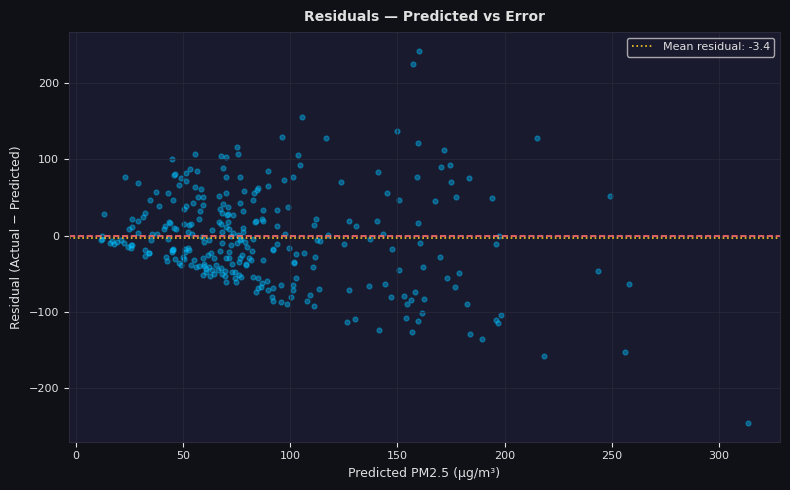

In [618]:
# ── Plot 3: Residuals ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)
ax.scatter(y_pred, residuals, alpha=0.4, s=12, color=BLUE)
ax.axhline(0, color=RED, linestyle='--', linewidth=1.2)
ax.axhline(residuals.mean(), color=YELLOW, linestyle=':',
           linewidth=1.2, label=f'Mean residual: {residuals.mean():.1f}')
ax.legend(fontsize=8, labelcolor=TEXT, facecolor=BG)
style(ax, "Residuals — Predicted vs Error",
      "Predicted PM2.5 (µg/m³)", "Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

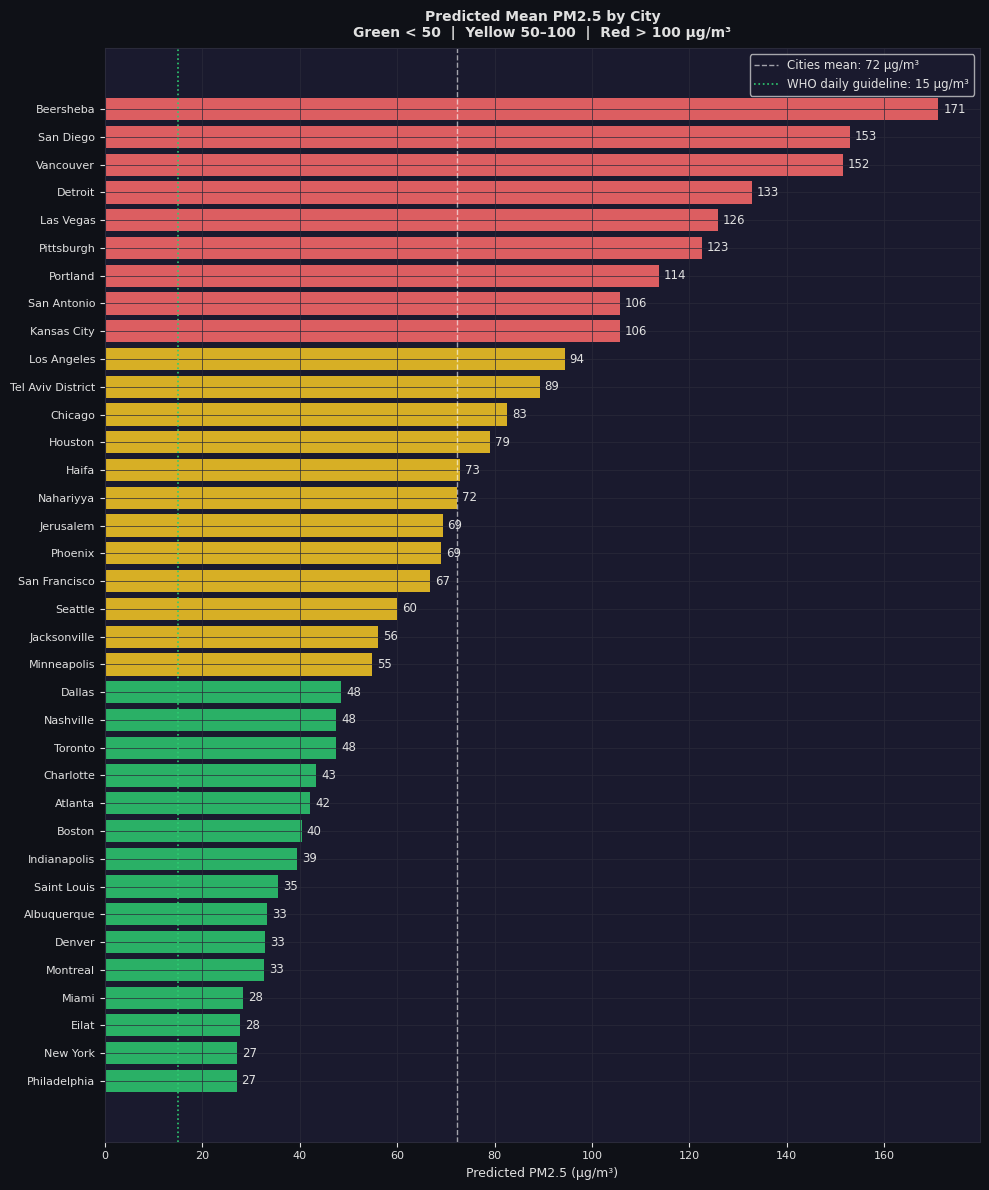

In [619]:
# ── Plot 4: City ranking ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12), facecolor=FIG_BG)
bar_colors = [GREEN  if v < 50  else
              YELLOW if v < 100 else
              RED    for v in city_ranking['predicted_PM2.5']]

bars4 = ax.barh(city_ranking['city'], city_ranking['predicted_PM2.5'],
                color=bar_colors, alpha=0.85)

for bar, val in zip(bars4, city_ranking['predicted_PM2.5']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', color=TEXT, fontsize=8.5)
    
ax.axvline(city_ranking['predicted_PM2.5'].mean(), color='white',
           linestyle='--', linewidth=1, alpha=0.6,
           label=f"Cities mean: {city_ranking['predicted_PM2.5'].mean():.0f} µg/m³")

ax.axvline(15, color=GREEN, linestyle=':', linewidth=1.2,
           label='WHO daily guideline: 15 µg/m³')

ax.legend(fontsize=8.5, labelcolor=TEXT, facecolor=BG)
style(ax, "Predicted Mean PM2.5 by City\nGreen < 50  |  Yellow 50–100  |  Red > 100 µg/m³",
      "Predicted PM2.5 (µg/m³)", "")

ax.grid(axis='x', color=GRID, linewidth=0.5)
plt.tight_layout()
plt.show()

### Answers to Research Questions

1. To what extent do meteorological conditions (wind speed, temperature, pressure) influence PM2.5 concentration in Beijing?

In [630]:
corr = df_air[['PM2.5','temperature','pressure','wind_speed']].corr()['PM2.5'].drop('PM2.5')
print(corr.sort_values())

wind_speed    -0.276821
temperature   -0.129700
pressure      -0.003686
Name: PM2.5, dtype: float64


By the correlation analysis and feature importances. 
- Wind speed (−0.277)
- Temperature (−0.130)
- Pressure    (-0.004)

All show measurable relationships with PM2.5.

The Random Forest model quantified their combined contribution at R²=0.237 — meaning weather explains 24% of PM2.5 variance.

2. Can pollution driven by human activity be distinguished from pollution exacerbated by atmospheric stagnation?

In [629]:

# emission vs weather
emission_corr = df_air[['PM2.5', 'CO', 'NO2', 'SO2']].corr()['PM2.5'].drop('PM2.5')
weather_corr  = df_air[['PM2.5', 'wind_speed', 'temperature', 'DEWP']].corr()['PM2.5'].drop('PM2.5')

print("Emission variables:")
print(emission_corr.sort_values())
print("\nWeather variables:")
print(weather_corr.sort_values())

Emission variables:
SO2    0.479181
NO2    0.681161
CO     0.786035
Name: PM2.5, dtype: float64

Weather variables:
wind_speed    -0.276821
temperature   -0.129700
DEWP           0.118637
Name: PM2.5, dtype: float64


Emission variables (CO, NO2, SO2) are very strongly, strongly and moderate correlated with PM2.5.

Weather variables (WSPM, TEMP, DEWP) are weakly correlated.

This confirms that human activity is the dominant driver of PM2.5

3. Based on meteorological conditions, which cities experience atmospheric conditions most favourable for air quality?

Answered by the city ranking, plot 4.

Philadelphia, New York, Eilat and Miami sit below 30 µg/m³ 
predicted PM2.5 — their wind speed and temperature profiles favour pollutant dispersion. 

Beersheba, San Diego and Vancouver exceed 150 µg/m³ — their met conditions mirror Beijing's stagnant, high-pollution days.


### Interpretation
Overall range: 27 → 171 µg/m³

Every city sits above the WHO daily guideline of 15 µg/m³. This is partly the model - the model was trained on Beijing data where the mean PM2.5 is 83 µg/m³, so predictions are anchored to a heavily polluted baseline. 

These are not absolute PM2.5 values — they reflect how similar each city's meteorological profile is to Beijing's clean vs polluted days.


**Top 5 cleanest** — Philadelphia, New York, Eilat, Miami, Montreal (27–33 µg/m³)

These cities share relatively consistent wind speeds and temperature profiles that the model associates with Beijing's lower-pollution days. Philadelphia and New York benefiting here is counterintuitive given their urban density — the model only sees met variables, not emission sources.

**Mid-range** — Minneapolis to Houston (54–79 µg/m³)
Mixed bag of inland US cities. Their met conditions fall close to Beijing's average. No strong signal either way.

**Bottom 5 worst** — Pittsburgh, Las Vegas, Detroit, Vancouver, San Diego, Beersheba (122–171 µg/m³)
Their temperature-pressure-wind combinations most closely resemble Beijing's high-pollution days.

Vancouver and San Diego scoring this poorly is the most surprising finding — both are coastal cities with reputations for clean air. 

This signal a limitation of the model: their coastal temperature-pressure profiles happen to mirror Beijing's stagnant winter patterns numerically, even though the underlying pollution drivers are completely different.

## Geographic Pattern

| Group          | Cities                                    | Predicted PM2.5 | Pattern                                                        |
|----------------|-------------------------------------------|-----------------|----------------------------------------------------------------|
| US East Coast  | Philadelphia, New York, Boston, Miami     | 27–40           | Consistently clean                                             |
| Israel         | Eilat vs Beersheba                        | 28 vs 171       | Widest spread in any country — desert vs coastal climate       |
| US West Coast  | San Francisco, LA, San Diego, Portland    | 67–153          | Consistently poor                                              |
| Canada         | Montreal vs Vancouver                     | 33 vs 152       | Opposite ends of the ranking                                   |

**Verdict**

The ranking is meteorologically coherent — wind speed drives it most (importance 0.375), see plot 1. 

Cities with met conditions that favour dispersion rank well. But with R²=0.237 and RMSE=62 µg/m³, the specific numbers are unreliable.

The ranking order is more trustworthy than the values. 

A city ranked 1st is likely to have more favourable air dispersion conditions than one ranked 35th — but you cannot say Philadelphia's air is precisely 27 µg/m³.


### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* 

To get a reliable city ranking, the next step would be sourcing actual PM2.5 measurements for these 36 cities rather than estimating from met variables alone.